In [17]:
# Install the FRED API library
!pip install fredapi

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred

# Authenticate with my API key
fred = Fred(api_key='api key')

Data I am trying to get:

* CPIAUCSL: Consumer Price Index (The Inflation Measure)
* AHETPI: Average Hourly Earnings of Production Employees (The Wage Measure)

In [19]:
# 1. Fetch the data series
print("Fetching data from FRED...")
wages = fred.get_series('AHETPI')
cpi = fred.get_series('CPIAUCSL')

# 2. Combine into a DataFrame
df = pd.DataFrame({'Nominal_Wage': wages, 'CPI': cpi})

# 3. Drop missing values because the wage data starts later than CPI data
df = df.dropna()

# Inspect the raw data
print(df.head())
print(df.tail())

Fetching data from FRED...
            Nominal_Wage    CPI
1964-01-01          2.50  30.94
1964-02-01          2.50  30.91
1964-03-01          2.51  30.94
1964-04-01          2.52  30.95
1964-05-01          2.52  30.98
            Nominal_Wage      CPI
2025-07-01         31.35  322.132
2025-08-01         31.45  323.364
2025-09-01         31.52  324.368
2025-11-01         31.73  325.031
2025-12-01         31.76  326.030


In [20]:
def get_real_wage(nominal_col, cpi_col):
    """
    Takes a nominal column and a CPI column.
    Returns a new column adjusted for inflation (Real Dollars).
    """
    # 1. Get the CPI of the most recent date (Today's Prices)
    cpi_today = cpi_col.iloc[-1]

    # 2. The Formula: (Nominal / Old_CPI) * CPI_Today
    real_col = (nominal_col / cpi_col) * cpi_today

    return real_col

# Apply the function to create a new column
df['Real_Wage'] = get_real_wage(df['Nominal_Wage'], df['CPI'])

# Check the result - Real Wages are different from Nominal!
print(df.tail())

            Nominal_Wage      CPI  Real_Wage
2025-07-01         31.35  322.132  31.729355
2025-08-01         31.45  323.364  31.709292
2025-09-01         31.52  324.368  31.681502
2025-11-01         31.73  325.031  31.827524
2025-12-01         31.76  326.030  31.760000


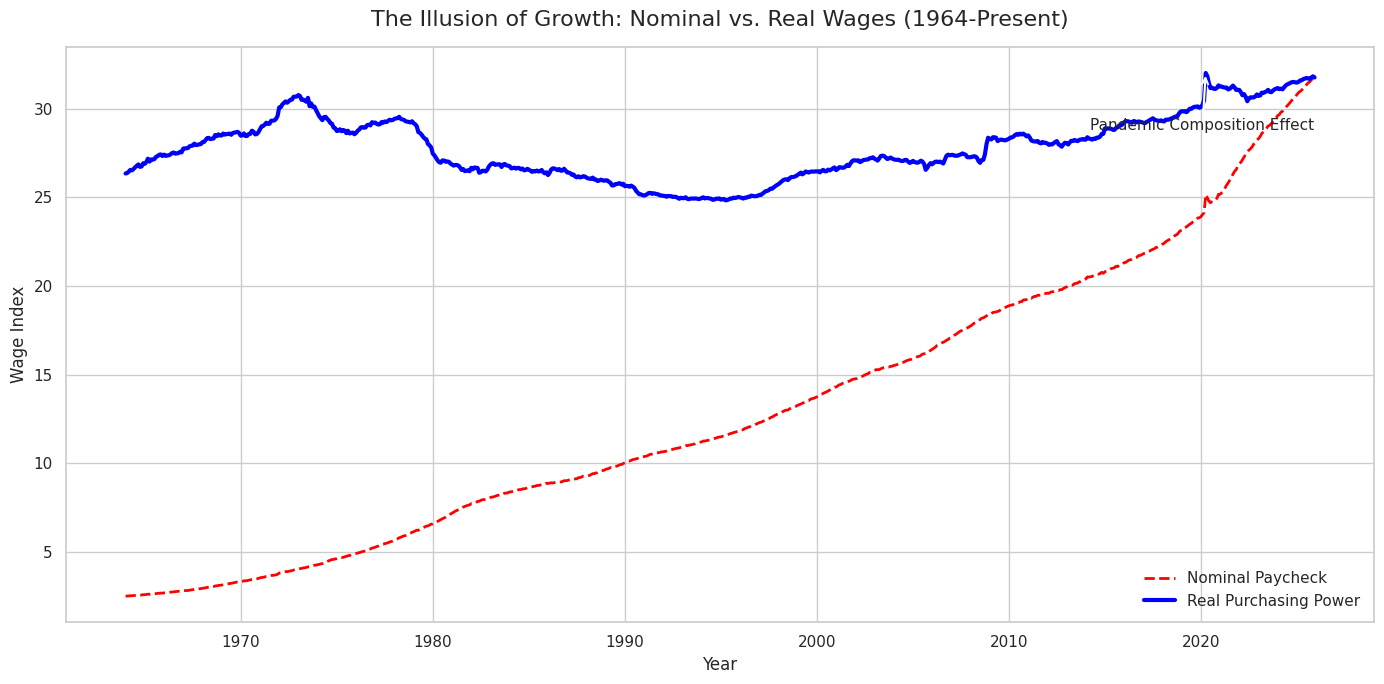

In [21]:
import seaborn as sns

# Style
sns.set_theme(style="whitegrid")

# Create figure
fig, ax = plt.subplots(figsize=(14, 7))

# Plot lines
ax.plot(
    df.index,
    df["Nominal_Wage"],
    linestyle="--",
    color="red",
    linewidth=2,
    label="Nominal Paycheck"
)

ax.plot(
    df.index,
    df["Real_Wage"],
    linestyle="-",
    color="blue",
    linewidth=3,
    label="Real Purchasing Power"
)

# Title and labels
ax.set_title(
    "The Illusion of Growth: Nominal vs. Real Wages (1964-Present)",
    fontsize=16,
    pad=15
)
ax.set_xlabel("Year")
ax.set_ylabel("Wage Index")

# --- Annotation: 2020 spike in real wages ---
# Find the peak in real wages during 2020
real_2020 = df.loc["2020", "Real_Wage"]
spike_date = real_2020.idxmax()
spike_value = real_2020.max()

ax.annotate(
    "Pandemic Composition Effect",
    xy=(spike_date, spike_value),
    xytext=(spike_date - pd.DateOffset(years=6), spike_value * 0.9),
    arrowprops=dict(arrowstyle="->", linewidth=1.5),
    fontsize=11
)

# Legend and layout
ax.legend(frameon=False)
plt.tight_layout()

plt.show()

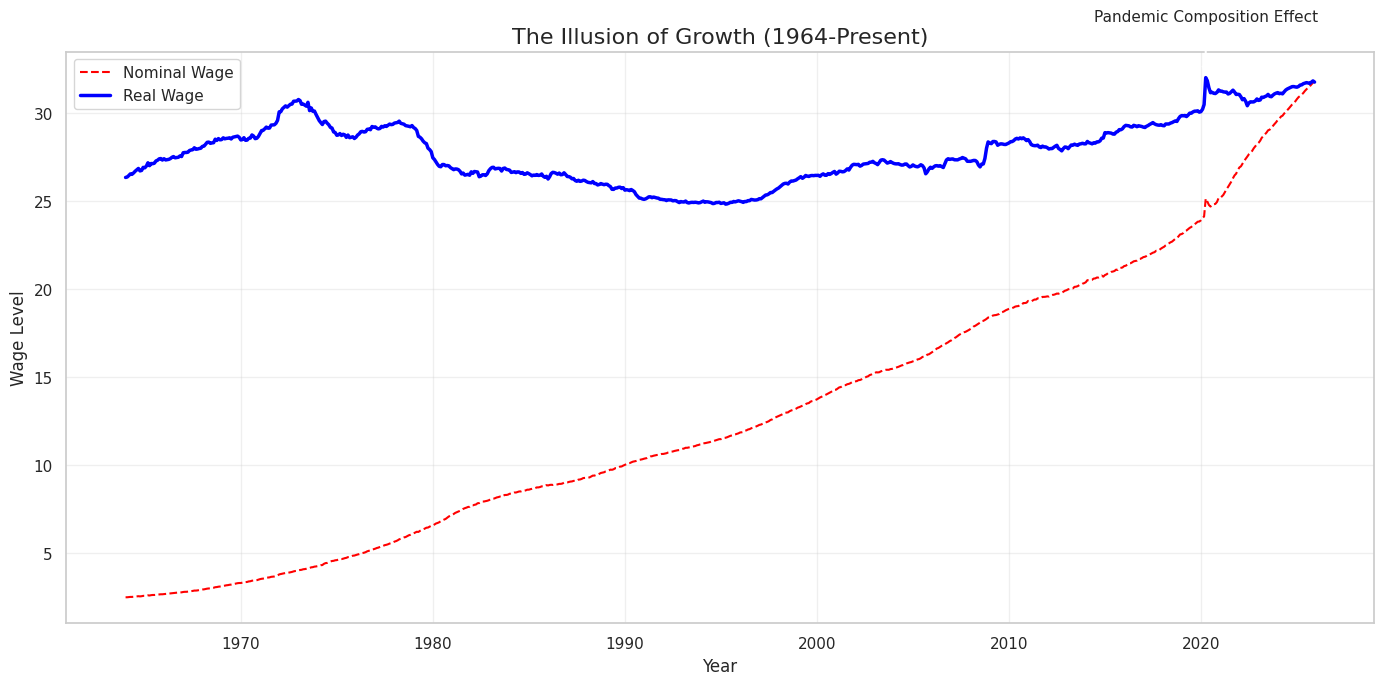

In [22]:
# Create figure
fig, ax = plt.subplots(figsize=(14, 7))

# Plot lines
ax.plot(df.index, df['Nominal_Wage'],
        linestyle='--',
        color='red',
        label='Nominal Wage')

ax.plot(df.index, df['Real_Wage'],
        linestyle='-',
        color='blue',
        linewidth=2.5,
        label='Real Wage')

# Title and labels
ax.set_title('The Illusion of Growth (1964-Present)', fontsize=16)
ax.set_xlabel('Year')
ax.set_ylabel('Wage Level')

# Locate 2020 point for annotation
df_2020 = df.loc['2020']
x_2020 = df_2020['Real_Wage'].idxmax()
y_2020 = df_2020.loc[x_2020, 'Real_Wage']

ax.annotate(
    'Pandemic Composition Effect',
    xy=(x_2020, y_2020),
    xytext=(x_2020, y_2020 * 1.1),
    arrowprops=dict(arrowstyle='->', linewidth=1.5),
    fontsize=11,
    ha='center'
)

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The blue line, real wage,  isn't completely flat but it is a lot flatter compared to the red line, nominal wage.

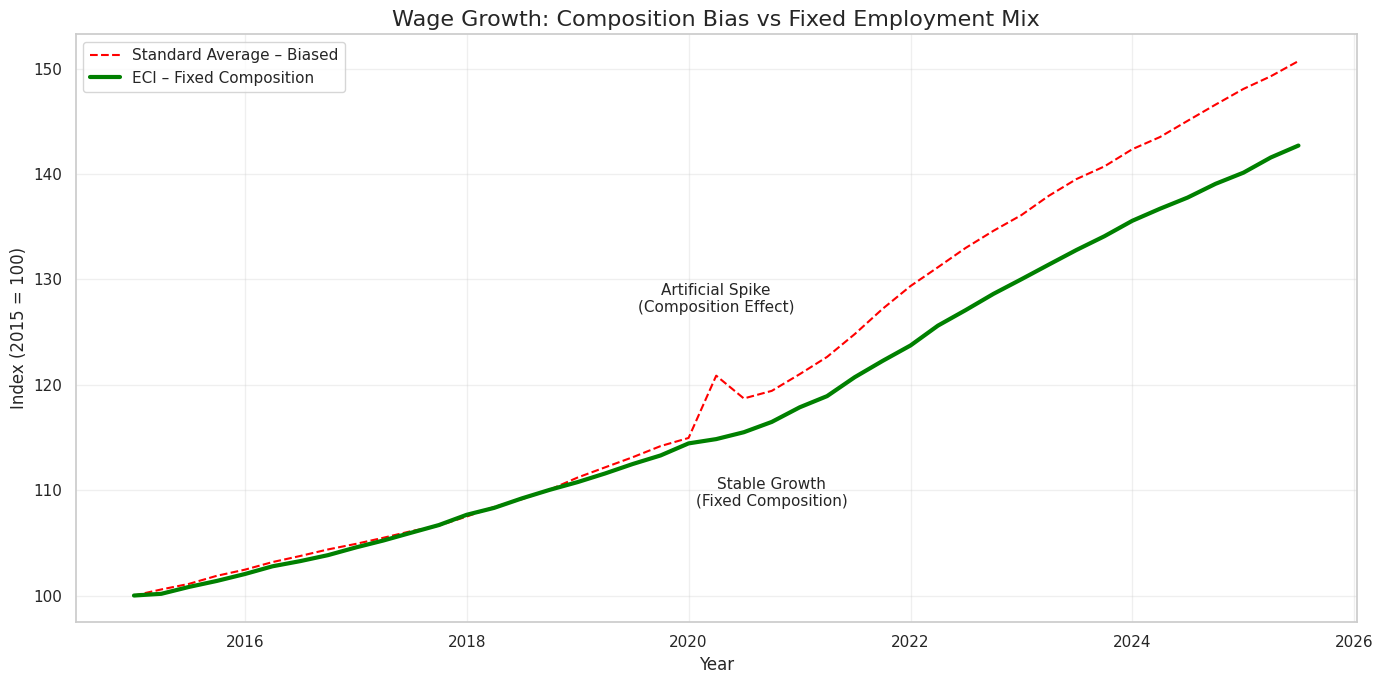

In [23]:
# 1. Fetch ECI series from FRED
eci = fred.get_series('ECIWAG')

# 2. Filter both series from 2015 onward
wages_2015 = wages.loc['2015-01-01':]
eci_2015 = eci.loc['2015-01-01':]

# Align indexes (important for clean plotting)
wages_2015, eci_2015 = wages_2015.align(eci_2015, join='inner')

# 3. Rebase both series to 100
wages_rebased = (wages_2015 / wages_2015.iloc[0]) * 100
eci_rebased = (eci_2015 / eci_2015.iloc[0]) * 100

# 4. Plot
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    wages_rebased.index,
    wages_rebased,
    linestyle='--',
    color='red',
    label='Standard Average – Biased'
)

ax.plot(
    eci_rebased.index,
    eci_rebased,
    linestyle='-',
    color='green',
    linewidth=3,
    label='ECI – Fixed Composition'
)

ax.set_title('Wage Growth: Composition Bias vs Fixed Employment Mix', fontsize=16)
ax.set_ylabel('Index (2015 = 100)')
ax.set_xlabel('Year')

# 5. Annotate 2020 divergence
w_2020 = wages_rebased.loc['2020']
e_2020 = eci_rebased.loc['2020']

x_w = w_2020.idxmax()
y_w = w_2020.max()

x_e = e_2020.idxmax()
y_e = e_2020.max()

ax.annotate(
    'Artificial Spike\n(Composition Effect)',
    xy=(x_w, y_w),
    xytext=(x_w, y_w + 6),
    arrowprops=dict(arrowstyle='->', linewidth=1.5),
    fontsize=11,
    ha='center'
)

ax.annotate(
    'Stable Growth\n(Fixed Composition)',
    xy=(x_e, y_e),
    xytext=(x_e, y_e - 8),
    arrowprops=dict(arrowstyle='->', linewidth=1.5),
    fontsize=11,
    ha='center'
)

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()